# **Báo cáo đề tài: Object Detection - Phát hiện vật thể**

## **Mục tiêu:**
* Xác định vị trí (Bounding Box) và phân loại nhiều vật thể trong cùng một bức ảnh.

# **Notebook này là môi trường thử nghiệm**
* Sử dụng tập val2017 chứa 5000 ảnh để kiểm tra tính đúng đắn của toàn bộ quy trình, phát hiện và sửa lỗi nhanh chóng trên tập dữ liệu nhỏ trước khi áp dụng vào tập dữ liệu lớn là tập train2017 với hơn 118k ảnh
* Lý do: Tập train2017 quá lớn (18GB, 118k ảnh), gây tốn thời gian tải và xử lý khi đang sửa code. Việc dùng tập val giúp vòng lặp sửa code, chạy thử diễn ra nhanh hơn.


## **Kiến trúc mô hình:**
* Backbone (ResNet/FPN): Sử dụng ResNet để trích xuất đặc trưng và FPN (Feature Pyramid Network) để giúp mô hình nhận diện tốt vật thể ở nhiều kích thước khác nhau (lớn và nhỏ).
* Detection Head (YOLOstyle): Phần "đầu" dự đoán được thiết kế theo phong cách của YOLO (You Only Look Once), nổi tiếng với tốc độ xử lý nhanh.
* Bộ dữ liệu: COCO 2017: Hơn 200.000 hình ảnh, 80 danh mục vật thể, gồm:
  * Tập huấn luyện (Train 2017): Khoảng 118.000 ảnh. Dùng để huấn luyện chính cho mô hình.
  * Tập kiểm định (Val 2017): 5.000 ảnh. Dùng để kiểm tra hiệu suất và tinh chỉnh siêu tham số trong quá trình huấn luyện.
  * Tập kiểm thử (Test 2017): Khoảng 41.000 ảnh. Là tập kiểm thử. Do tập test 2017 không công khai nhãn (dùng riêng cho các cuộc thi) nên sẽ dùng tập val 2017 để đánh giá kết quả thực nghiệm
  * Tập chứa dữ liệu nhãn (annotations): Đây là các file định dạng JSON chứa tọa độ khung hình, tên đồ vật cho cả tập train và val. Dùng để đánh giá cuối cùng.

## **Các chỉ số chú ý trong báo cáo**
* mAP (Mean Average Precision): Đây là chỉ số quan trọng nhất để biết mô hình của bạn chính xác đến mức nào trên tất cả các loại vật thể.
* AP50: Độ chính xác khi khung hình chữ nhật của bạn khớp với đáp án ít nhất 50% (IoU > 0.5).
* Visualize: Vẽ các khung hình chữ nhật (bounding boxes) lên ảnh thực tế để kiểm tra bằng mắt thường.



# **Step 1: Setup & Connection**

Kết nối với Google Drive để lưu trữ checkpoint và kết quả.
- checkpoints: Thư mục chứa file model (.pth).
- results: Thư mục chứa ảnh dự đoán và biểu đồ loss.

In [1]:
import os
try:
    from google.colab import drive
    drive.mount('/content/drive')
    print("Da ket noi Google Drive.")

    # Định nghĩa các thư mục lưu trữ
    base_dir = '/content/drive/MyDrive/DL_Object_Detection_Report'
    checkpoint_dir = os.path.join(base_dir, 'checkpoints')
    results_dir = os.path.join(base_dir, 'results')

    os.makedirs(checkpoint_dir, exist_ok=True)
    os.makedirs(results_dir, exist_ok=True)
    print(f"Thu muc Checkpoints: {checkpoint_dir}")
    print(f"Thu muc Results: {results_dir}")

except ImportError:
    checkpoint_dir = './checkpoints'
    results_dir = './results'
    os.makedirs(checkpoint_dir, exist_ok=True)
    os.makedirs(results_dir, exist_ok=True)

Mounted at /content/drive
Da ket noi Google Drive.
Thu muc Checkpoints: /content/drive/MyDrive/DL_Object_Detection_Report/checkpoints
Thu muc Results: /content/drive/MyDrive/DL_Object_Detection_Report/results


# **Step 2: Dataset Preparation - Chuẩn bị dữ liệu**

Tải trực tiếp tập dữ liệu COCO 2017 Validation về môi trường Colab.

In [2]:
import time

# Thư mục dữ liệu tạm trên SSD của Colab
DATA_ROOT = '/content/coco_data_temp'
os.makedirs(DATA_ROOT, exist_ok=True)
%cd {DATA_ROOT}

print("Dang tai du lieu (Val2017)")

# 1. Tải file nhãn (Annotations)
if not os.path.exists('annotations_trainval2017.zip'):
    !curl -O http://images.cocodataset.org/annotations/annotations_trainval2017.zip
    !unzip -q annotations_trainval2017.zip

# 2. Tải file ảnh (Images)
if not os.path.exists('val2017.zip'):
    !curl -O http://images.cocodataset.org/zips/val2017.zip
    !unzip -q val2017.zip

print("Du lieu da san sang.")

/content/coco_data_temp
Dang tai du lieu (Val2017)
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  241M  100  241M    0     0  41.4M      0  0:00:05  0:00:05 --:--:-- 45.2M
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  777M  100  777M    0     0  59.1M      0  0:00:13  0:00:13 --:--:-- 63.7M
Du lieu da san sang.


## **Step 2.1: Dataset Exploration (EDA) - Khám phá dữ liệu**


In [3]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

ann_file = os.path.join(DATA_ROOT, 'annotations/instances_val2017.json')
img_dir = os.path.join(DATA_ROOT, 'val2017')

if os.path.exists(ann_file):
    with open(ann_file, 'r') as f:
        coco_data = json.load(f)
    print("Da tai file Annotation JSON thanh cong!")
else:
    print("Chua tim thay file JSON.")

Da tai file Annotation JSON thanh cong!


In [4]:
# 1. Xem các trường thông tin chính (Keys)
print(f"Cac keys trong file JSON: {list(coco_data.keys())}")

Cac keys trong file JSON: ['info', 'licenses', 'images', 'annotations', 'categories']


In [5]:
# 2. Thống kê số lượng
print(f"Tong so anh (images): {len(coco_data['images'])}")
print(f"Tong so nhan vat the (annotations): {len(coco_data['annotations'])}")

Tong so anh (images): 5000
Tong so nhan vat the (annotations): 36781


In [6]:
# 3. Danh sách (list) chứa thông tin về tất cả các danh mục vật thể (object categories)
coco_data['categories']

[{'supercategory': 'person', 'id': 1, 'name': 'person'},
 {'supercategory': 'vehicle', 'id': 2, 'name': 'bicycle'},
 {'supercategory': 'vehicle', 'id': 3, 'name': 'car'},
 {'supercategory': 'vehicle', 'id': 4, 'name': 'motorcycle'},
 {'supercategory': 'vehicle', 'id': 5, 'name': 'airplane'},
 {'supercategory': 'vehicle', 'id': 6, 'name': 'bus'},
 {'supercategory': 'vehicle', 'id': 7, 'name': 'train'},
 {'supercategory': 'vehicle', 'id': 8, 'name': 'truck'},
 {'supercategory': 'vehicle', 'id': 9, 'name': 'boat'},
 {'supercategory': 'outdoor', 'id': 10, 'name': 'traffic light'},
 {'supercategory': 'outdoor', 'id': 11, 'name': 'fire hydrant'},
 {'supercategory': 'outdoor', 'id': 13, 'name': 'stop sign'},
 {'supercategory': 'outdoor', 'id': 14, 'name': 'parking meter'},
 {'supercategory': 'outdoor', 'id': 15, 'name': 'bench'},
 {'supercategory': 'animal', 'id': 16, 'name': 'bird'},
 {'supercategory': 'animal', 'id': 17, 'name': 'cat'},
 {'supercategory': 'animal', 'id': 18, 'name': 'dog'},

In [7]:
# 4. Bảng thông tin ảnh (Images)
val_im_df = pd.DataFrame(coco_data['images'])
val_im_df = val_im_df[['id', 'file_name', 'height', 'width']]
val_im_df.rename(columns={'id': 'image_id'}, inplace=True) # Doi ten cot id thanh image_id de merge
print("Thong tin Images (20 dong dau):")
display(val_im_df.head(20))

Thong tin Images (20 dong dau):


,image_id,file_name,height,width
0,397133,000000397133.jpg,427,640
1,37777,000000037777.jpg,230,352
2,252219,000000252219.jpg,428,640
3,87038,000000087038.jpg,480,640
4,174482,000000174482.jpg,388,640
5,403385,000000403385.jpg,511,640
6,6818,000000006818.jpg,640,427
7,480985,000000480985.jpg,500,375
8,458054,000000458054.jpg,426,640
9,331352,000000331352.jpg,500,351


In [8]:
# 5. Chỉ số trung bình, cao nhất, thấp nhất ảnh tập dữ liệu coco2017
df_images = pd.DataFrame(coco_data['images'])

mean_h = df_images['height'].mean()
mean_w = df_images['width'].mean()

max_h = df_images['height'].max()
max_w = df_images['width'].max()

min_h = df_images['height'].min()
min_w = df_images['width'].min()

print(f" THỐNG KÊ KÍCH THƯỚC ẢNH ({len(df_images)} ảnh):")
print(f" Chiều cao trung bình: {mean_h:.1f} pixel")
print(f" Chiều rộng trung bình: {mean_w:.1f} pixel")
print(f" Kích thước lớn nhất: {max_w} x {max_h}")
print(f" Kích thước nhỏ nhất: {min_w} x {min_h}")

 THỐNG KÊ KÍCH THƯỚC ẢNH (5000 ảnh):
 Chiều cao trung bình: 483.5 pixel
 Chiều rộng trung bình: 573.8 pixel
 Kích thước lớn nhất: 640 x 640
 Kích thước nhỏ nhất: 200 x 145


In [9]:
# 6. Bảng nhãn (Annotations)
val_anno_df = pd.DataFrame(coco_data['annotations'])
val_anno_df = val_anno_df[['image_id', 'bbox', 'category_id', 'id']]
print("Thong tin Annotations (20 dong dau):")
display(val_anno_df.head(20))

Thong tin Annotations (20 dong dau):


,image_id,bbox,category_id,id
0,289343,"[473.07, 395.93, 38.65, 28.67]",18,1768
1,61471,"[272.1, 200.23, 151.97, 279.77]",18,1773
2,472375,"[124.71, 196.18, 372.85, 356.81]",18,2551
3,520301,"[112.71, 154.82, 367.29, 479.35]",18,3186
4,579321,"[200.61, 89.65, 400.22, 251.02]",18,3419
5,494869,"[0.0, 421.09, 154.53, 208.61]",18,3658
6,554002,"[427.58, 77.87, 188.88, 285.91]",18,4594
7,78823,"[197.97, 117.22, 170.45, 222.07]",18,7544
8,419974,"[61.68, 389.34, 130.77, 138.47]",18,7915
9,404484,"[86.93, 90.76, 82.5, 74.54]",18,7981


In [12]:
# 7. Merge Data: Ghép bảng Ảnh và Nhãn
''' Mục đích: Kết hợp thông tin để biết chính xác mỗi file ảnh chứa những vật thể gì và kích thước ra sao.
Kiểm tra và đổi tên cột 'id' thành 'image_id' trong val_im_df nếu cần thiết'''

if 'id' in val_im_df.columns and 'image_id' not in val_im_df.columns:
    val_im_df.rename(columns={'id': 'image_id'}, inplace=True)

merged_df = pd.merge(val_anno_df, val_im_df, on='image_id', how='inner')

# Map thêm tên Category vào bảng tổng hợp
# Khởi tạo cat_df từ coco_data['categories']
cat_df = pd.DataFrame(coco_data['categories'])
merged_df = pd.merge(merged_df, cat_df[['id', 'name']], left_on='category_id', right_on='id', how='left')
print("Bang du lieu TONG HOP (Merged DataFrame)")
display(merged_df[['image_id', 'file_name', 'bbox', 'name']].head(20))

Bang du lieu TONG HOP (Merged DataFrame)


,image_id,file_name,bbox,name
0,289343,000000289343.jpg,"[473.07, 395.93, 38.65, 28.67]",dog
1,61471,000000061471.jpg,"[272.1, 200.23, 151.97, 279.77]",dog
2,472375,000000472375.jpg,"[124.71, 196.18, 372.85, 356.81]",dog
3,520301,000000520301.jpg,"[112.71, 154.82, 367.29, 479.35]",dog
4,579321,000000579321.jpg,"[200.61, 89.65, 400.22, 251.02]",dog
5,494869,000000494869.jpg,"[0.0, 421.09, 154.53, 208.61]",dog
6,554002,000000554002.jpg,"[427.58, 77.87, 188.88, 285.91]",dog
7,78823,000000078823.jpg,"[197.97, 117.22, 170.45, 222.07]",dog
8,419974,000000419974.jpg,"[61.68, 389.34, 130.77, 138.47]",dog
9,404484,000000404484.jpg,"[86.93, 90.76, 82.5, 74.54]",dog


In [14]:
# 8. Thống kê phân bố
print(f"Tong so vat the (Objects): {len(merged_df)}")
print(f"Tong so anh chua vat the: {merged_df['image_id'].nunique()}")

# Top 10 object xuat hien nhieu nhat
print("\n50 Class pho bien nhat:")
print(merged_df['name'].value_counts().head(50))

Tong so vat the (Objects): 36781
Tong so anh chua vat the: 4952

50 Class pho bien nhat:
name
person           11004
car               1932
chair             1791
book              1161
bottle            1025
cup                899
dining table       697
traffic light      637
bowl               626
handbag            540
bird               440
boat               430
truck              415
umbrella           413
bench              413
cow                380
banana             379
motorcycle         371
carrot             371
backpack           371
sheep              361
wine glass         343
potted plant       343
donut              338
kite               336
knife              326
broccoli           316
cake               316
bicycle            316
suitcase           303
tv                 288
orange             287
pizza              285
bus                285
remote             283
vase               277
horse              273
surfboard          269
zebra              268
clock    

In [28]:
# 9. Kiểm tra từng vật thể (annotation)
missing_labels = merged_df['name'].isnull().sum()

print(f"Phát hiện {missing_labels} vật thể bị mất nhãn (không có tên).")

Phát hiện 0 vật thể bị mất nhãn (không có tên).


In [29]:
# 10. Kiểm tra dữ liệu có lỗi / bất thường hay không
merged_df['bbox_width'] = merged_df['bbox'].apply(lambda x: x[2])
merged_df['bbox_height'] = merged_df['bbox'].apply(lambda x: x[3])

invalid_bbox = merged_df[
    (merged_df['bbox_width'] <= 0) |
    (merged_df['bbox_height'] <= 0)
]

print("Số Lượng bbox lỗi:", len(invalid_bbox))

Số Lượng bbox lỗi: 0


In [30]:
# 11. Kiểm tra ảnh có tồn tại nhưng không có bbox
all_image_ids = set(df_images['id'])
annotated_image_ids = set(val_anno_df['image_id'])

empty_images = all_image_ids - annotated_image_ids

print("Số ảnh không có annotation:", len(empty_images))
print("Tỉ lệ:", len(empty_images) / len(all_image_ids))

Số ảnh không có annotation: 48
Tỉ lệ: 0.0096


## **Step 2.2: Exploratory Data Visualization (EDV)- Trực quan hóa dữ liệu khám phá**

### 1. Phân bố số lượng object theo từng class

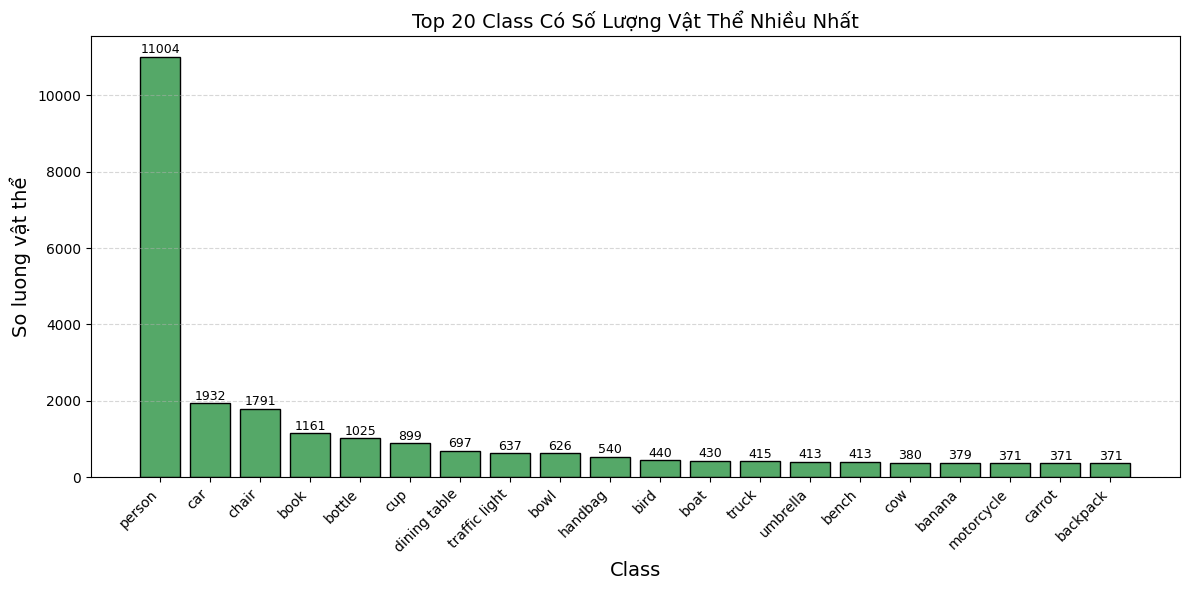

In [31]:
class_count = merged_df['name'].value_counts()
top20_class = class_count.head(20)

plt.figure(figsize=(12, 6))

# Thêm viền đen cho cột nổi bật hơn
bars = plt.bar(
    top20_class.index,
    top20_class.values,
    color='#55A868',   # xanh la
    edgecolor='black'  # Thêm viền đen
)

# Viết số lên đầu mỗi cột
for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        yval + 10,
        int(yval),
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.title('Top 20 Class Có Số Lượng Vật Thể Nhiều Nhất', fontsize=14)
plt.xlabel('Class', fontsize=14)
plt.ylabel('So luong vật thể', fontsize=14)
plt.xticks(rotation=45, ha='right')

plt.grid(axis='y', linestyle='--', alpha=0.5) # Thêm lưới ngang mờ
plt.tight_layout()
plt.show()

### 2. Phân bố số object trên mỗi ảnh

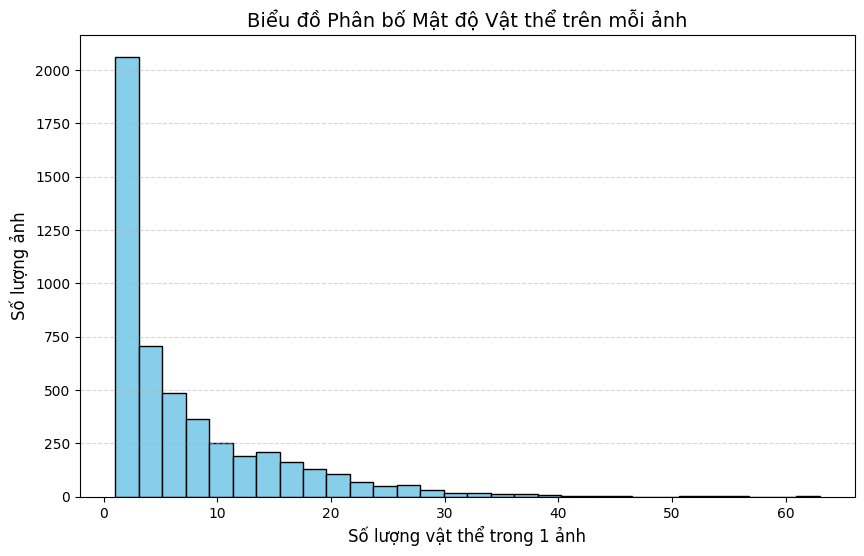


 KẾT QUẢ THỐNG KÊ MẬT ĐỘ:

 Ảnh Ít Vật Thể Nhất: 1 (vật thể)
 Ảnh Nhiều Vật Thể Nhất: 63 (vật thể)
 Trung Bình Vật Thể Mỗi Ảnh: 7.4 (vật thể


In [32]:
# Đếm xem mỗi ID ảnh xuất hiện bao nhiêu lần trong bảng
mat_do_vat_the = merged_df.groupby('image_id').size()

plt.figure(figsize=(10, 6))

# Vẽ cột màu xanh
plt.hist(mat_do_vat_the, bins=30, color='skyblue', edgecolor='black')

plt.title('Biểu đồ Phân bố Mật độ Vật thể trên mỗi ảnh', fontsize=14)
plt.xlabel('Số lượng vật thể trong 1 ảnh', fontsize=12)
plt.ylabel('Số lượng ảnh', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5) # Thêm dòng kẻ ngang mờ mờ cho dễ dóng số
plt.show()

print("\n KẾT QUẢ THỐNG KÊ MẬT ĐỘ:\n")
print(f" Ảnh Ít Vật Thể Nhất: {mat_do_vat_the.min()} (vật thể)")
print(f" Ảnh Nhiều Vật Thể Nhất: {mat_do_vat_the.max()} (vật thể)")
print(f" Trung Bình Vật Thể Mỗi Ảnh: {mat_do_vat_the.mean():.1f} (vật thể")




### 3. Phân tích kích thước bounding box (width, height, area)

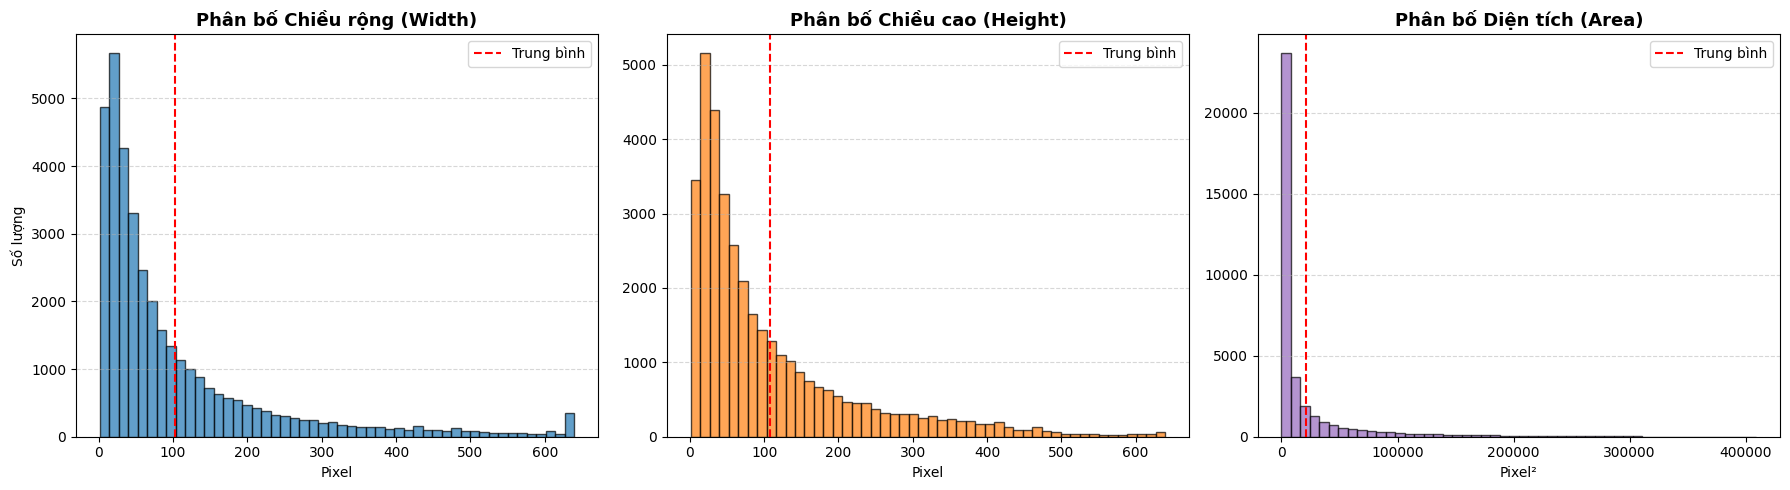


THỐNG KÊ KÍCH THƯỚC KHUNG

Chiều rộng TB:  103.0 pixel
Chiều cao TB:   107.3 pixel
Chiều rộng cao nhất:  640.0 pixel)
Chiều cao cao nhất:   640.0 pixel)
Diện tích TB:   21307 pixel²


In [33]:
merged_df['bbox_width'] = merged_df['bbox'].apply(lambda x: x[2])
merged_df['bbox_height'] = merged_df['bbox'].apply(lambda x: x[3])
merged_df['bbox_area'] = merged_df['bbox_width'] * merged_df['bbox_height']

plt.figure(figsize=(18, 5))

# Biểu đồ 1: Chiều rộng (Width)
plt.subplot(1, 3, 1)
plt.hist(merged_df['bbox_width'], bins=50, color='#1f77b4', edgecolor='black', alpha=0.7)
plt.axvline(merged_df['bbox_width'].mean(), color='red', linestyle='dashed', linewidth=1.5, label='Trung bình')
plt.title('Phân bố Chiều rộng (Width)', fontsize=13, fontweight='bold')
plt.xlabel('Pixel')
plt.ylabel('Số lượng')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Biểu đồ 2: Chiều cao (Height)
plt.subplot(1, 3, 2)
plt.hist(merged_df['bbox_height'], bins=50, color='#ff7f0e', edgecolor='black', alpha=0.7)
plt.axvline(merged_df['bbox_height'].mean(), color='red', linestyle='dashed', linewidth=1.5, label='Trung bình')
plt.title('Phân bố Chiều cao (Height)', fontsize=13, fontweight='bold')
plt.xlabel('Pixel')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Biểu đồ 3: Diện tích (Area)
plt.subplot(1, 3, 3)
plt.hist(merged_df['bbox_area'], bins=50, color='#9467bd', edgecolor='black', alpha=0.7)
plt.axvline(merged_df['bbox_area'].mean(), color='red', linestyle='dashed', linewidth=1.5, label='Trung bình')
plt.title('Phân bố Diện tích (Area)', fontsize=13, fontweight='bold')
plt.xlabel('Pixel²')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# IN THỐNG KÊ CHI TIẾT
print("\nTHỐNG KÊ KÍCH THƯỚC KHUNG\n")

print(f"Chiều rộng TB:  {merged_df['bbox_width'].mean():.1f} pixel")
print(f"Chiều cao TB:   {merged_df['bbox_height'].mean():.1f} pixel")

print(f"Chiều rộng cao nhất:  {merged_df['bbox_width'].max()} pixel)")
print(f"Chiều cao cao nhất:   {merged_df['bbox_height'].max()} pixel)")

print(f"Diện tích TB:   {merged_df['bbox_area'].mean():.0f} pixel²")


### 4. Phân bố tỉ lệ khung hình (Aspect Ratio)

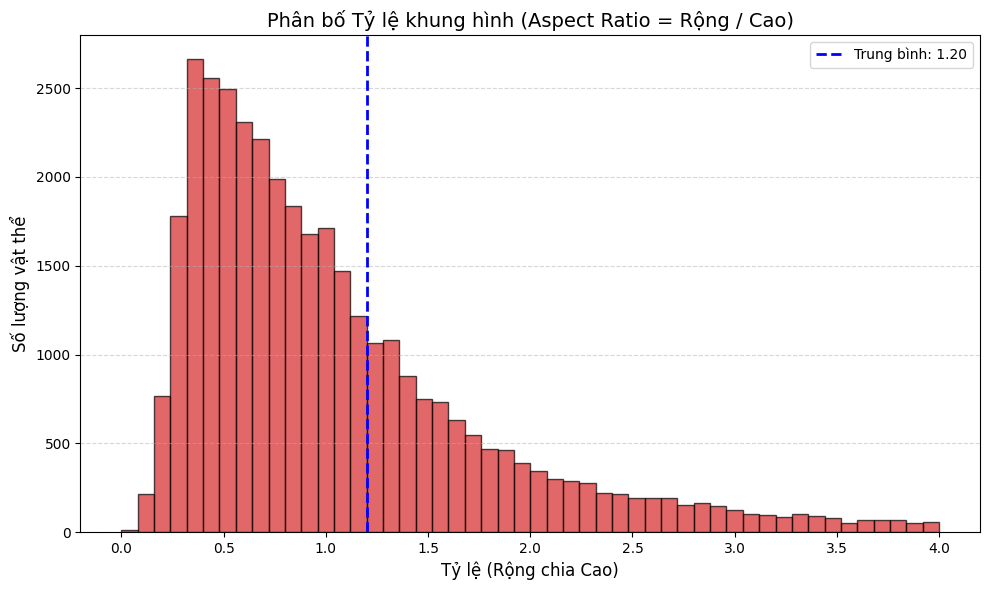


Ý NGHĨA CỦA TỶ LỆ

Tỷ lệ trung bình: 1.20
Ratio > 1: Vật thể bè ngang (Chiều rộng > Chiều cao)
Ratio < 1: Vật thể cao gầy (Chiều cao > Chiều rộng)
Ratio = 1: Vật thể hình vuông


In [34]:
import matplotlib.pyplot as plt

# TÍNH TỶ LỆ
# Aspect Ratio = Rộng / Cao
# > 1: Vật thể nằm ngang (Xe ô tô, giường...)
# < 1: Vật thể thẳng đứng (Người, chai nước...)
# = 1: Hình vuông (Biển báo, đồng hồ...)
merged_df['aspect_ratio'] = merged_df['bbox_width'] / merged_df['bbox_height']

plt.figure(figsize=(10, 6))

# Vẽ histogram, nhưng giới hạn range từ 0 đến 4 để nhìn cho rõ
plt.hist(merged_df['aspect_ratio'], bins=50, range=(0, 4), color='#d62728', edgecolor='black', alpha=0.7)

# Vẽ đường trung bình
plt.axvline(merged_df['aspect_ratio'].mean(), color='blue', linestyle='--', linewidth=2, label=f'Trung bình: {merged_df["aspect_ratio"].mean():.2f}')


plt.title('Phân bố Tỷ lệ khung hình (Aspect Ratio = Rộng / Cao)', fontsize=14)
plt.xlabel('Tỷ lệ (Rộng chia Cao)', fontsize=12)
plt.ylabel('Số lượng vật thể', fontsize=12)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# THỐNG KÊ
print("\nÝ NGHĨA CỦA TỶ LỆ\n")

print(f"Tỷ lệ trung bình: {merged_df['aspect_ratio'].mean():.2f}")
print("Ratio > 1: Vật thể bè ngang (Chiều rộng > Chiều cao)")
print("Ratio < 1: Vật thể cao gầy (Chiều cao > Chiều rộng)")
print("Ratio = 1: Vật thể hình vuông")


### 5. Phân loại small / medium / large object

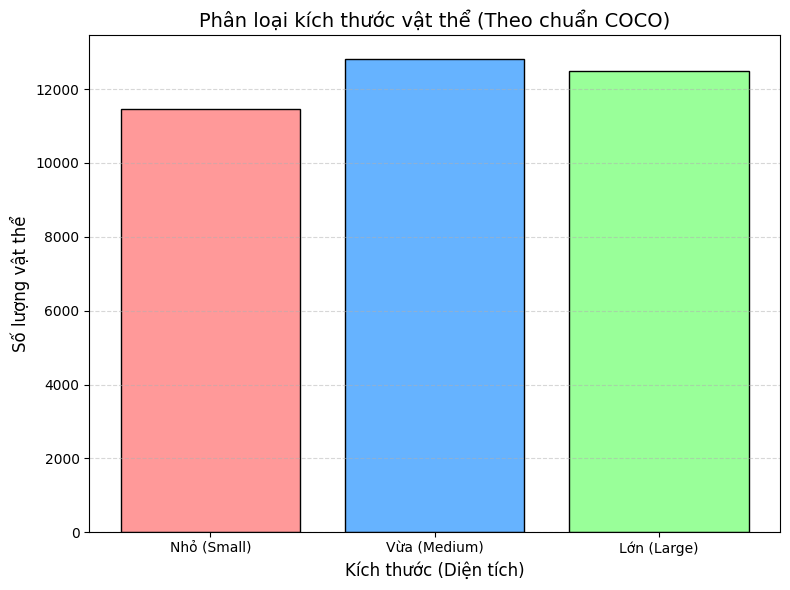


THỐNG KÊ CHI TIẾT KÍCH THƯỚC:

Tiêu chuẩn COCO:
Nhỏ: < 32x32 pixel
Vừa: Từ 32x32 đến 96x96 pixel
Lớn: > 96x96 pixel


In [35]:
# ĐỊNH NGHĨA HÀM PHÂN LOẠI (Theo chuẩn COCO)
def size_category(area):
    if area < 32 * 32:
        return 'Nhỏ (Small)'    # Diện tích < 1024 px²
    elif area < 96 * 96:
        return 'Vừa (Medium)'   # 1024 < Diện tích < 9216 px²
    else:
        return 'Lớn (Large)'    # Diện tích > 9216 px²

# ÁP DỤNG VÀO DATAFRAME
merged_df['object_size'] = merged_df['bbox_area'].apply(size_category)

# Đếm số lượng
size_count = merged_df['object_size'].value_counts()

# Sắp xếp lại thứ tự
order = ['Nhỏ (Small)', 'Vừa (Medium)', 'Lớn (Large)']
# Chỉ lấy những loại có trong dữ liệu
existing_order = [o for o in order if o in size_count.index]
size_count = size_count.reindex(existing_order)

plt.figure(figsize=(8, 6))
bars = plt.bar(size_count.index, size_count.values, color=['#ff9999', '#66b3ff', '#99ff99'], edgecolor='black')


plt.title('Phân loại kích thước vật thể (Theo chuẩn COCO)', fontsize=14)
plt.xlabel('Kích thước (Diện tích)', fontsize=12)
plt.ylabel('Số lượng vật thể', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

print("\nTHỐNG KÊ CHI TIẾT KÍCH THƯỚC:\n")
print("Tiêu chuẩn COCO:")
print("Nhỏ: < 32x32 pixel")
print("Vừa: Từ 32x32 đến 96x96 pixel")
print("Lớn: > 96x96 pixel")


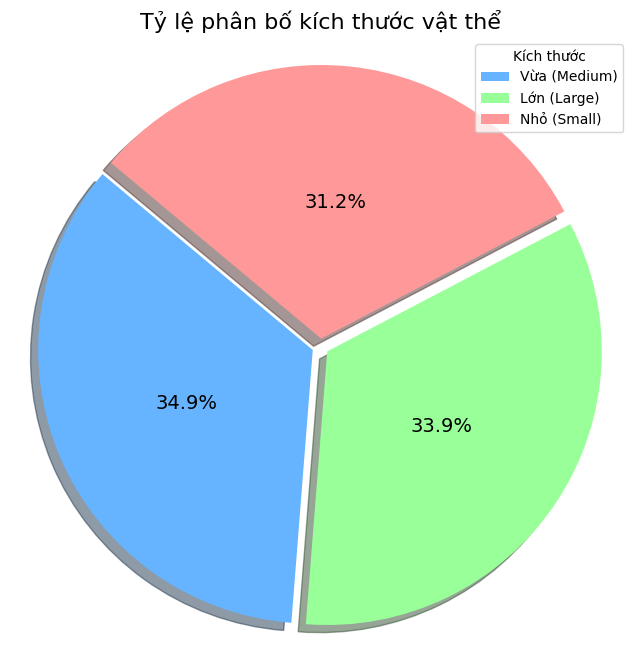

In [76]:
plt.figure(figsize=(8, 8))
colors = ['#66b3ff', '#99ff99', '#ff9999']
explode = (0.03, 0.03, 0.03)

plt.pie(
    size_count,
    labels=None,
    autopct='%1.1f%%',
    startangle=140,
    colors=colors,
    explode=explode,
    shadow=True,
    textprops={'fontsize': 14},
    pctdistance=0.5
)

plt.title('Tỷ lệ phân bố kích thước vật thể', fontsize=16)
plt.legend(labels=size_count.index, title="Kích thước", loc="best")
plt.axis('equal')
plt.show()

6. Trực quan hóa nhãn Ground Truth trên ảnh

In [79]:
import random
import cv2
import matplotlib.pyplot as plt

def visualize_gt(
    merged_df,
    img_dir,
    val_im_df,
    num_images=6,
    show_label=False
):
    sample_images = random.sample(list(val_im_df['file_name']), num_images)

    cols = 3
    rows = (num_images + cols - 1) // cols
    plt.figure(figsize=(15, 5 * rows))

    for i, img_name in enumerate(sample_images):
        img_path = f"{img_dir}/{img_name}"
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        img_id = val_im_df[val_im_df['file_name'] == img_name]['image_id'].values[0]
        anns = merged_df[merged_df['image_id'] == img_id]

        for _, row in anns.iterrows():
            x, y, w, h = row['bbox']
            cv2.rectangle(
                img,
                (int(x), int(y)),
                (int(x + w), int(y + h)),
                (255, 0, 0),
                2
            )
            if show_label:
                cv2.putText(
                    img,
                    row['name'],
                    (int(x), int(y - 5)),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.5,
                    (255, 255, 0),
                    2
                )

        plt.subplot(rows, cols, i + 1)
        plt.imshow(img)
        plt.axis("off")
        plt.title(img_name)

    plt.tight_layout()
    plt.show()


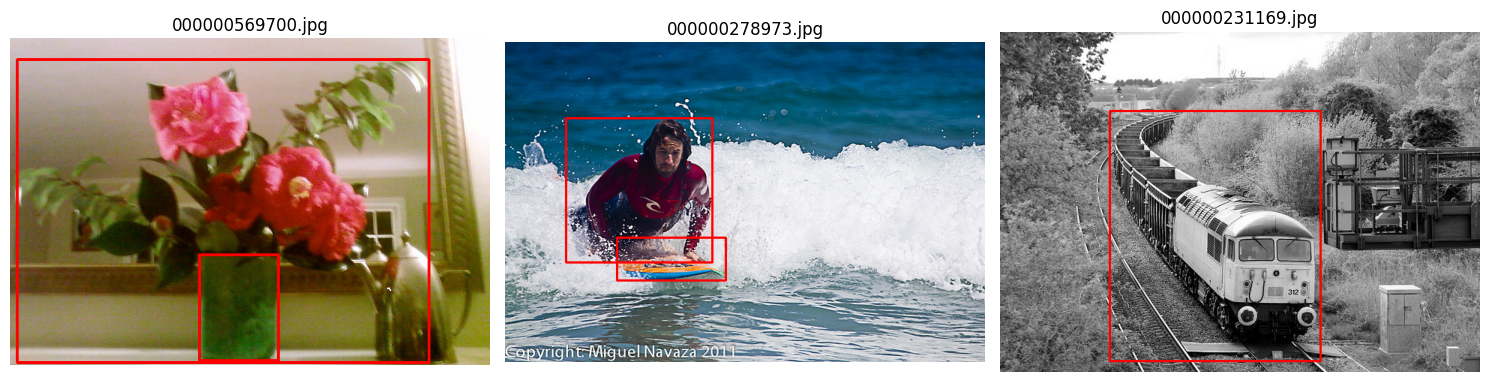

In [154]:
visualize_gt(
    merged_df,
    img_dir="val2017",
    val_im_df=val_im_df,
    num_images=3,
    show_label=False
)


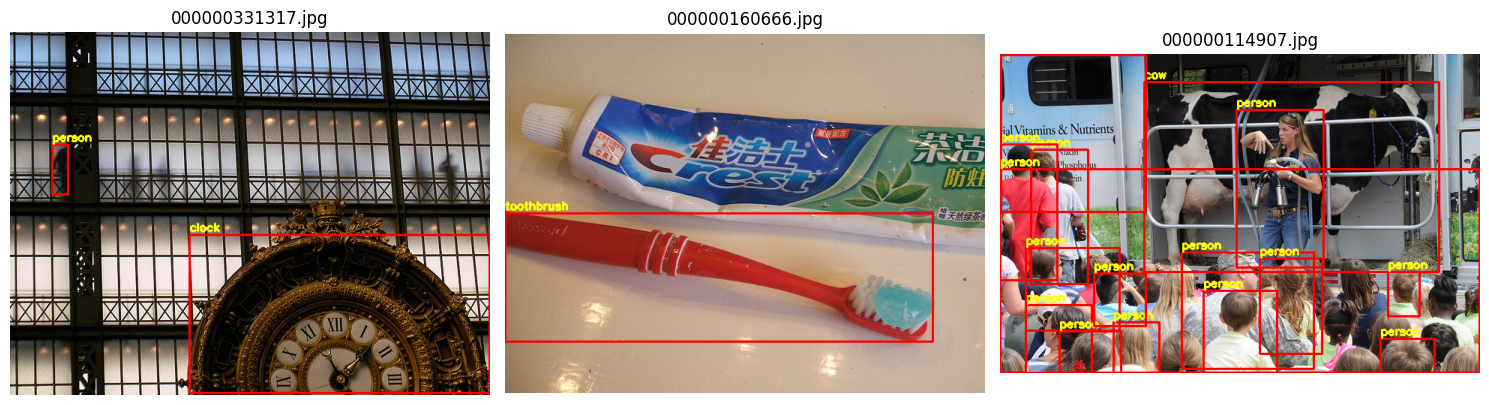

In [173]:
visualize_gt(
    merged_df,
    img_dir="val2017",
    val_im_df=val_im_df,
    num_images=3,
    show_label=True
)


## **Step 2.3: Data Preprocessing**

 **1. Resize (Thay đổi kích thước):**
 *   Dữ liệu ảnh đầu vào có kích thước không đồng nhất.
 *   **Giải pháp:** Sử dụng cơ chế `Generalized R-CNN Transform` tự động trong Model.
 *   **Cấu hình:** `min_size=480`, `max_size=640`. Mọi ảnh sẽ được rescale để cạnh ngắn nhất đạt 480px.

 **2. Normalize (Chuẩn hóa):**
 *   Ảnh gốc có pixels ở đoạn `[0, 255]`.
 *   **Giải pháp:** Chuyển đổi sang `Tensor` và chia 255 để về đoạn `[0, 1]`.

 **3. Split Dataset (Chia tập dữ liệu):**
 *   **Train:** Sử dụng `train2017`. **Validation:** Sử dụng `val2017`.

In [97]:
import torch
from torch.utils.data import Dataset, DataLoader
import cv2
import numpy as np
from torchvision.transforms import functional as F

# Lớp Dataset tùy chỉnh cho COCO
class CocoDataset(Dataset):
    def __init__(self, root, annotation, max_samples=None):
        from pycocotools.coco import COCO
        self.root = root
        self.coco = COCO(annotation)
        # Sắp xếp và chỉ lấy 1 phần dữ liệu nếu cần test nhanh
        self.ids = list(sorted(self.coco.imgs.keys()))
        if max_samples:
            self.ids = self.ids[:max_samples]
            print(f"Da gioi han dataset con {len(self.ids)} anh de chay nhanh!")

    def __getitem__(self, index):
        coco = self.coco
        img_id = self.ids[index]
        path = coco.loadImgs(img_id)[0]['file_name']
        img_path = os.path.join(self.root, path)

        img = cv2.imread(img_path)
        if img is None:
            # Trả về ảnh đen nếu lỗi đọc
            return torch.zeros((3, 224, 224), dtype=torch.float32), {}

        # Chuyển đổi hệ màu BGR (OpenCV) -> RGB (PyTorch hiển thị chuẩn)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        # Hàm F.to_tensor thực hiện 2 việc:
        # 1. Chuyển đổi mảng numpy (H, W, C) sang Tensor (C, H, W)
        # 2. CHUẨN HÓA giá trị pixel từ [0, 255] về [0.0, 1.0]
        img = F.to_tensor(img)

        ann_ids = coco.getAnnIds(imgIds=img_id)
        coco_annotation = coco.loadAnns(ann_ids)

        boxes = []
        labels = []
        for i in range(len(coco_annotation)):
            xmin, ymin, w, h = coco_annotation[i]['bbox']
            boxes.append([xmin, ymin, xmin+w, ymin+h])
            labels.append(coco_annotation[i]['category_id'])

        target = {}
        if len(boxes) > 0:
            target["boxes"] = torch.as_tensor(boxes, dtype=torch.float32)
            target["labels"] = torch.as_tensor(labels, dtype=torch.int64)
        else:
            target["boxes"] = torch.zeros((0, 4), dtype=torch.float32)
            target["labels"] = torch.zeros((0,), dtype=torch.int64)

        # Thêm image_id vào target để có thể sử dụng khi tính mAP
        target["image_id"] = torch.tensor([img_id])

        return img, target

    def __len__(self):
        return len(self.ids)

val_dir = os.path.join(DATA_ROOT, 'val2017')
val_ann = os.path.join(DATA_ROOT, 'annotations/instances_val2017.json')

# CẤU HÌNH DATASET TỐI ƯU
dataset = CocoDataset(val_dir, val_ann, max_samples= None)

# CẤU HÌNH DATALOADER TỐI ƯU
# Batch_size = 2
data_loader = DataLoader(
    dataset,
    batch_size=4,
    shuffle=True,
    collate_fn=lambda x: tuple(zip(*x)),
    num_workers=2
)

print(f"DataLoader da khoi tao thanh cong. So luong Batch: {len(data_loader)}")

loading annotations into memory...
Done (t=0.81s)
creating index...
index created!
DataLoader da khoi tao thanh cong. So luong Batch: 1250


# **Step 3: Model Initialization - Khởi tạo mô hình**

Khởi tạo mạng RetinaNet (với backbone ResNet-50) và cài đặt logic khôi phục huấn luyện (resume).

In [174]:
import torchvision
from torchvision.models.detection import retinanet_resnet50_fpn

device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
print(f"Thiet bi huan luyen: {device}")

# 1. Tải mô hình đã được huấn luyện sẵn (Pre-trained)
# CẤU HÌNH MODEL (TỐI ƯU TỐC ĐỘ)
# Giảm min_size xuống 480 để nhẹ hơn, max_size 640
print("Dang khoi tao model RetinaNet (Optimization Mode: Small Image Size")
model = retinanet_resnet50_fpn(weights='DEFAULT', min_size=480, max_size=640)

model.to(device)

# 2. Bộ tối ưu hóa (Optimizer)
params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(params, lr=0.001, momentum=0.9, weight_decay=0.0005)

# 3. Logic khôi phục (Resume)
resume_path = os.path.join(checkpoint_dir, 'full_state_checkpoint.pth')
start_epoch = 0
loss_history = []

if os.path.exists(resume_path):
    print(f"Tim thay Checkpoint cu tai: {resume_path}")
    print("Dang tai lai trang thai (Model + Optimizer)...")

    checkpoint = torch.load(resume_path, map_location=device)

    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    start_epoch = checkpoint['epoch'] + 1
    loss_history = checkpoint.get('loss_history', [])

    print(f"Tiep tuc huan luyen tu Epoch {start_epoch}.")
else:
    print("Khong tim thay checkpoint. Bat dau huan luyen moi (Epoch 0).")

print("Mo hinh da san sang.")

Thiet bi huan luyen: cuda
Dang khoi tao model RetinaNet (Optimization Mode: Small Image Size
Tim thay Checkpoint cu tai: /content/drive/MyDrive/DL_Object_Detection_Report/checkpoints/full_state_checkpoint.pth
Dang tai lai trang thai (Model + Optimizer)...
Tiep tuc huan luyen tu Epoch 12.
Mo hinh da san sang.


# **Step 4: Training Process - Quá trình huấn luyện**

Vòng lặp huấn luyện chính với tính năng tự động lưu

In [101]:
num_epochs = 12
print(f"Bat dau vong lap huan luyen tu Epoch {start_epoch} den {num_epochs-1}")

# Khởi tạo list lưu loss chi tiết (nếu chưa có)
if 'cls_loss_history' not in globals(): cls_loss_history = []
if 'box_loss_history' not in globals(): box_loss_history = []

for epoch in range(start_epoch, num_epochs):
    model.train()
    print(f"\nBat dau Epoch {epoch}")

    for i, (images, targets) in enumerate(data_loader):
        images = list(image.to(device) for image in images)
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        if len(targets)==0 or 'boxes' not in targets[0]: continue

        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())

        # TÁCH RIÊNG CÁC LOSS
        loss_cls = loss_dict['classification'].item() # Mất mát phân loại
        loss_box = loss_dict['bbox_regression'].item() # Mất mát vị trí

        optimizer.zero_grad()
        losses.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 0.5)
        optimizer.step()

        loss_history.append(losses.item())
        cls_loss_history.append(loss_cls) # Lưu lại
        box_loss_history.append(loss_box) # Lưu lại

        if i % 50 == 0:
            print(f"Epoch: {epoch} | Step: {i}/{len(data_loader)} | Total: {losses.item():.4f} | Cls: {loss_cls:.4f} | Box: {loss_box:.4f}")

            if i > 0 and i % 200 == 0:
                 save_info = {
                     'epoch': epoch,
                     'model_state_dict': model.state_dict(),
                     'optimizer_state_dict': optimizer.state_dict(),
                     'loss': losses.item(),
                     'loss_history': loss_history,
                     'cls_loss_history': cls_loss_history, # Lưu vào checkpoint
                     'box_loss_history': box_loss_history  # Lưu vào checkpoint
                 }
                 torch.save(save_info, resume_path)
                 print("Da tu dong luu checkpoint.")

    print(f"Hoan thanh Epoch {epoch}.")

    torch.save({
         'epoch': epoch,
         'model_state_dict': model.state_dict(),
         'optimizer_state_dict': optimizer.state_dict(),
         'loss': losses.item(),
         'loss_history': loss_history,
         'cls_loss_history': cls_loss_history,
         'box_loss_history': box_loss_history
    }, resume_path)
    print(f"Da luu Checkpoint cho Epoch {epoch}.")

Bat dau vong lap huan luyen tu Epoch 12 den 11


# **Step 5: Quantitative Results - Kết quả định lượng (Biểu đồ Loss)**


BIỂU ĐỒ 1: TỔNG HÀM MẤT MÁT (TOTAL LOSS)
Đã lưu biểu đồ: /content/drive/MyDrive/DL_Object_Detection_Report/results/loss_total.png


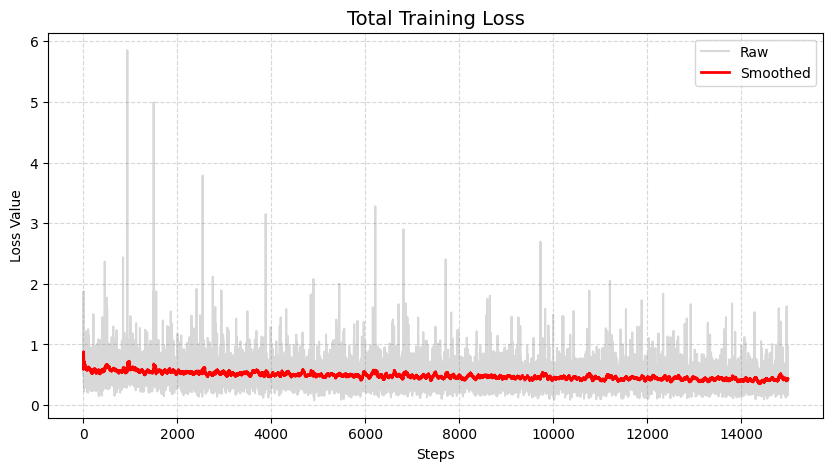


BIỂU ĐỒ 2: CLASSIFICATION LOSS (PHÂN LOẠI)
Chưa có dữ liệu cho biểu đồ: Classification Loss

BIỂU ĐỒ 3: LOCALIZATION LOSS (VỊ TRÍ KHUNG HÌNH)
Chưa có dữ liệu cho biểu đồ: Localization Loss (Bbox Regression)


In [175]:
import matplotlib.pyplot as plt
import pandas as pd
import os

# Hàm làm mượt dữ liệu
def smooth(data, window_size=50):
    if len(data) < window_size: return data
    return pd.Series(data).rolling(window=window_size, min_periods=1).mean()

# Hàm vẽ biểu đồ đơn lẻ
def plot_single_chart(data, title, color_raw, color_smooth, filename):
    if len(data) == 0:
        print(f"Chưa có dữ liệu cho biểu đồ: {title}")
        return

    plt.figure(figsize=(10, 5))
    # Vẽ đường gốc (mờ)
    plt.plot(data, label='Raw', color=color_raw, alpha=0.3)
    # Vẽ đường làm mượt (đậm)
    plt.plot(smooth(data), label='Smoothed', color=color_smooth, linewidth=2)

    plt.title(title, fontsize=14)
    plt.xlabel('Steps')
    plt.ylabel('Loss Value')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)

    # Lưu và hiển thị
    save_path = os.path.join(results_dir, filename)
    plt.savefig(save_path)
    print(f"Đã lưu biểu đồ: {save_path}")
    plt.show()

# Lấy dữ liệu an toàn
valid_total = loss_history if 'loss_history' in globals() else []
valid_cls = cls_loss_history if 'cls_loss_history' in globals() else []
valid_box = box_loss_history if 'box_loss_history' in globals() else []


print("\nBIỂU ĐỒ 1: TỔNG HÀM MẤT MÁT (TOTAL LOSS)")
plot_single_chart(valid_total, 'Total Training Loss', 'gray', 'red', 'loss_total.png')

print("\nBIỂU ĐỒ 2: CLASSIFICATION LOSS (PHÂN LOẠI)")
plot_single_chart(valid_cls, 'Classification Loss', 'lightblue', 'blue', 'loss_class.png')

print("\nBIỂU ĐỒ 3: LOCALIZATION LOSS (VỊ TRÍ KHUNG HÌNH)")
plot_single_chart(valid_box, 'Localization Loss (Bbox Regression)', 'lightgreen', 'green', 'loss_box.png')

# **Step 6: Qualitative Results - Kết quả định tính (Ảnh dự đoán)**

Da luu anh ket qua: /content/drive/MyDrive/DL_Object_Detection_Report/results/result_demo_0.jpg


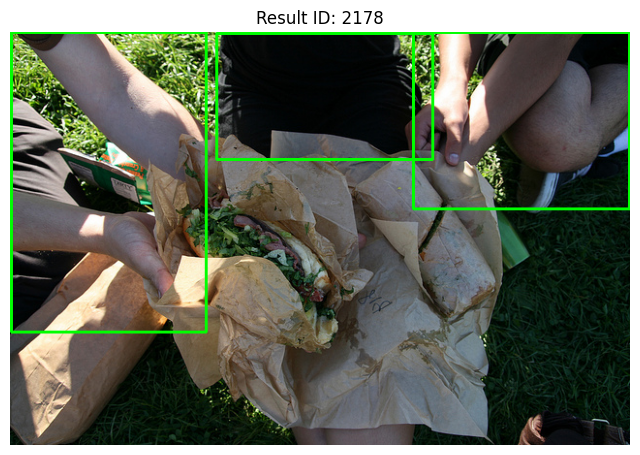

Da luu anh ket qua: /content/drive/MyDrive/DL_Object_Detection_Report/results/result_demo_1.jpg


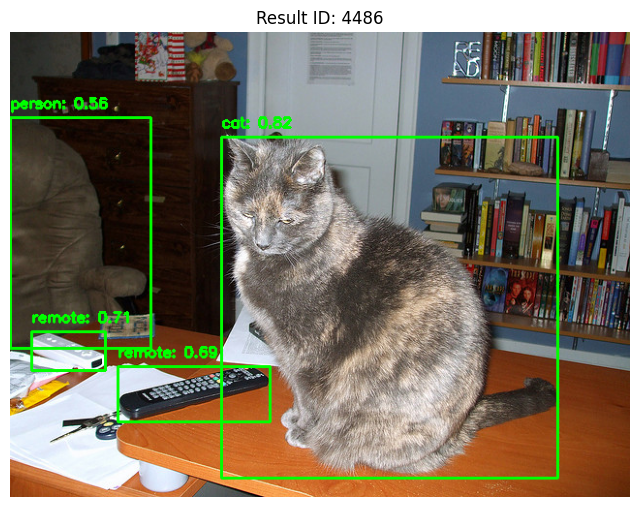

Da luu anh ket qua: /content/drive/MyDrive/DL_Object_Detection_Report/results/result_demo_2.jpg


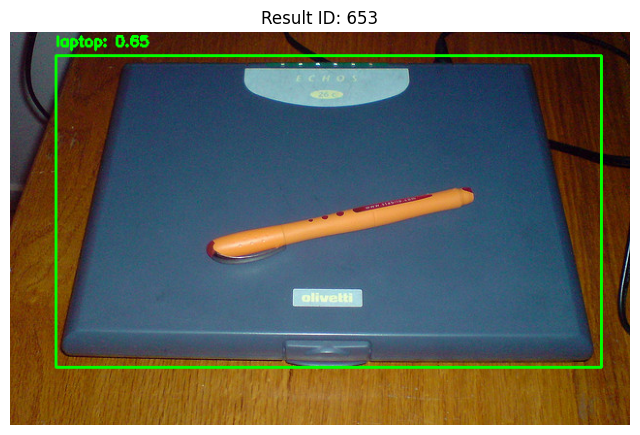

In [185]:
def visualize_and_save_results(count=3):
    model.eval()

    COCO_INSTANCE_CATEGORY_NAMES = [
        '__background__', 'person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus',
        'train', 'truck', 'boat', 'traffic light', 'fire hydrant', 'N/A', 'stop sign',
        'parking meter', 'bench', 'bird', 'cat', 'dog', 'horse', 'sheep', 'cow',
        'elephant', 'bear', 'zebra', 'giraffe', 'N/A', 'backpack', 'umbrella', 'N/A', 'N/A',
        'handbag', 'tie', 'suitcase', 'frisbee', 'skis', 'snowboard', 'sports ball',
        'kite', 'baseball bat', 'baseball glove', 'skateboard', 'surfboard', 'tennis racket',
        'bottle', 'N/A', 'wine glass', 'cup', 'fork', 'knife', 'spoon', 'bowl',
        'banana', 'apple', 'sandwich', 'orange', 'broccoli', 'carrot', 'hot dog', 'pizza',
        'donut', 'cake', 'chair', 'couch', 'potted plant', 'bed', 'N/A', 'dining table',
        'N/A', 'N/A', 'toilet', 'N/A', 'tv', 'laptop', 'mouse', 'remote', 'keyboard', 'cell phone',
        'microwave', 'oven', 'toaster', 'sink', 'refrigerator', 'N/A', 'book',
        'clock', 'vase', 'scissors', 'teddy bear', 'hair drier', 'toothbrush'
    ]

    indices = torch.randperm(len(dataset))[:count]

    for idx_count, idx in enumerate(indices):
        img, _ = dataset[idx]
        with torch.no_grad():
            prediction = model(img.unsqueeze(0).to(device))[0]

        img_np = img.permute(1, 2, 0).cpu().numpy().copy()
        img_np = cv2.cvtColor(img_np, cv2.COLOR_RGB2BGR)

        for i in range(len(prediction['boxes'])):
            score = prediction['scores'][i].cpu().numpy()
            if score > 0.5:
                box = prediction['boxes'][i].cpu().numpy().astype(int)
                label_id = prediction['labels'][i].cpu().numpy().astype(int)
                label_name = COCO_INSTANCE_CATEGORY_NAMES[label_id] if label_id < len(COCO_INSTANCE_CATEGORY_NAMES) else str(label_id)

                cv2.rectangle(img_np, (box[0], box[1]), (box[2], box[3]), (0, 255, 0), 2)
                cv2.putText(img_np, f"{label_name}: {score:.2f}", (box[0], box[1]-10),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

        file_name = os.path.join(results_dir, f"result_demo_{idx_count}.jpg")
        cv2.imwrite(file_name, img_np)
        print(f"Da luu anh ket qua: {file_name}")

        plt.figure(figsize=(8,8))
        plt.imshow(cv2.cvtColor(img_np, cv2.COLOR_BGR2RGB))
        plt.axis('off')
        plt.title(f"Result ID: {idx.item()}")
        plt.show()

visualize_and_save_results(3)

# **Step7: Phân tích lỗi sai (Error Analysis)**

* Màu Xanh Lá (Green): Ground Truth (Đáp án đúng - Thực tế).
* Màu Đỏ (Red): Prediction (Model dự đoán).

Đã lưu ảnh so sánh: /content/drive/MyDrive/DL_Object_Detection_Report/results/comparison_image_0.png


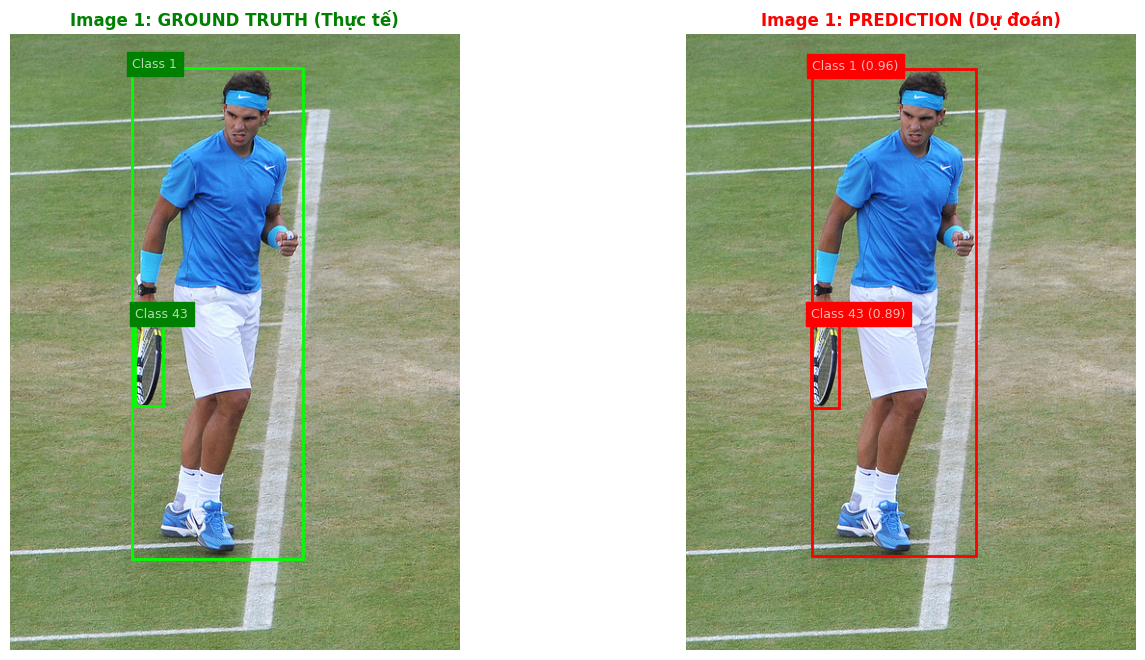

Đã lưu ảnh so sánh: /content/drive/MyDrive/DL_Object_Detection_Report/results/comparison_image_1.png


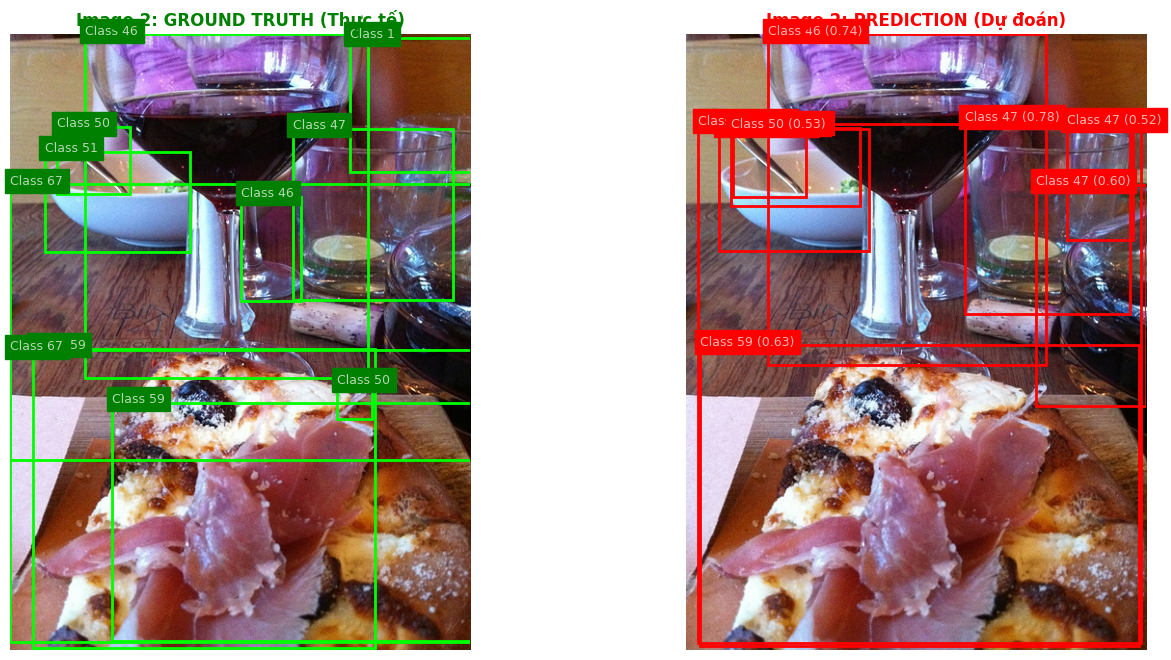

Đã lưu ảnh so sánh: /content/drive/MyDrive/DL_Object_Detection_Report/results/comparison_image_2.png


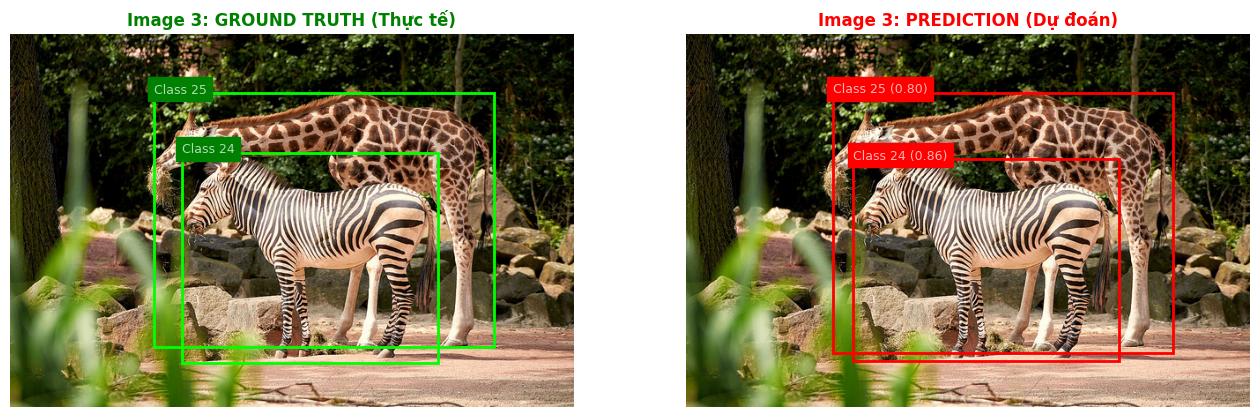

In [187]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import torch
import os

def visualize_side_by_side(model, data_loader, device, score_threshold=0.5, num_images=3):
    model.eval()
    images, targets = next(iter(data_loader))
    images = list(img.to(device) for img in images)

    with torch.no_grad():
        outputs = model(images)

    images = [img.cpu().numpy().transpose(1, 2, 0) for img in images]

    for i in range(min(num_images, len(images))):
        img_data = images[i]
        # Denormalize đơn giản (nếu cần, ở đây giả định ảnh 0-1)
        img_data = np.clip(img_data, 0, 1)

        # Tạo khung hình với 2 cột (Trái: GT, Phải: Pred)
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

        # HÌNH 1: GROUND TRUTH
        ax1.imshow(img_data)
        ax1.set_title(f"Image {i+1}: GROUND TRUTH (Thực tế)", color='green', fontweight='bold')
        ax1.axis('off')

        gt_boxes = targets[i]['boxes'].cpu().numpy()
        gt_labels = targets[i]['labels'].cpu().numpy()

        for box, label in zip(gt_boxes, gt_labels):
            x, y, w, h = box[0], box[1], box[2]-box[0], box[3]-box[1]
            # Vẽ khung XANH
            rect = patches.Rectangle((x, y), w, h, linewidth=2, edgecolor='lime', facecolor='none')
            ax1.add_patch(rect)
            ax1.text(x, y, f"Class {label}", color='white', fontsize=9, backgroundcolor='green', alpha=0.7)

        # HÌNH 2: PREDICTION
        ax2.imshow(img_data)
        ax2.set_title(f"Image {i+1}: PREDICTION (Dự đoán)", color='red', fontweight='bold')
        ax2.axis('off')

        pred_boxes = outputs[i]['boxes'].cpu().numpy()
        pred_labels = outputs[i]['labels'].cpu().numpy()
        pred_scores = outputs[i]['scores'].cpu().numpy()

        # Lọc ngưỡng tự tin
        keep = pred_scores >= score_threshold

        # Nếu không có dự đoán nào đạt ngưỡng
        if not keep.any():
             ax2.text(0.5, 0.5, "Không phát hiện vật thể", color='red', ha='center', transform=ax2.transAxes)
        else:
            for box, label, score in zip(pred_boxes[keep], pred_labels[keep], pred_scores[keep]):
                x, y, w, h = box[0], box[1], box[2]-box[0], box[3]-box[1]
                # Vẽ khung ĐỎ
                rect = patches.Rectangle((x, y), w, h, linewidth=2, edgecolor='red', facecolor='none')
                ax2.add_patch(rect)
                ax2.text(x, y, f"Class {label} ({score:.2f})", color='white', fontsize=9, backgroundcolor='red', alpha=0.7)

        # Lưu từng cặp ảnh
        save_path = os.path.join(results_dir, f'comparison_image_{i}.png')
        plt.savefig(save_path, bbox_inches='tight')
        print(f"Đã lưu ảnh so sánh: {save_path}")
        plt.show()

# Gọi hàm
visualize_side_by_side(model, data_loader, device, score_threshold=0.4, num_images=3)

# **Step 8: Calculate mAP - Đánh giá mAP**


Hàm dưới đây sẽ thực hiện đánh giá chi tiết theo chuẩn COCO (COCO-Style Evaluation) để tính ra các chỉ số quan trọng:
- **mAP (Average Precision @ IoU=0.50:0.95)**: Độ chính xác trung bình trên nhiều ngưỡng IoU.
- **AP50 (Average Precision @ IoU=0.50)**: Độ chính xác khi yêu cầu IoU > 0.5.

Kết quả sẽ được hiển thị dưới dạng bảng để bạn copy vào báo cáo.

In [110]:
# Cài đặt pycocotools nếu thiếu (thường Colab đã có sẵn)
try:
    from pycocotools.coco import COCO
    from pycocotools.cocoeval import COCOeval
except ImportError:
    !pip install pycocotools
    from pycocotools.coco import COCO
    from pycocotools.cocoeval import COCOeval
from tqdm import tqdm

def evaluate_coco_map(model, data_loader, device):
    model.eval()
    results = []

    print("Dang chay du doan de tinh mAP (Co the mat vai phut)...")
    with torch.no_grad():
        for images, targets in tqdm(data_loader):
            images = list(img.to(device) for img in images)

            # Chạy dự đoán
            outputs = model(images)

            # Đưa output về CPU
            outputs = [{k: v.to('cpu') for k, v in t.items()} for t in outputs]

            for i, output in enumerate(outputs):
                # Lấy image_id từ target mà ta đã thêm trong Dataset
                img_id = targets[i]['image_id'].item()

                boxes = output['boxes'].tolist()
                scores = output['scores'].tolist()
                labels = output['labels'].tolist()

                for box, score, label in zip(boxes, scores, labels):
                    # Convert box từ [x1, y1, x2, y2] sang [x, y, w, h] (Format COCO)
                    x, y, x2, y2 = box
                    w = x2 - x
                    h = y2 - y

                    results.append({
                        'image_id': img_id,
                        'category_id': label,
                        'bbox': [x, y, w, h],
                        'score': score
                    })

    if len(results) == 0:
        print("Khong detect duoc object nao! Hay check lai model.")
        return

    # Ghi kết quả tạm thời ra file JSON
    result_file = 'temp_results.json'
    with open(result_file, 'w') as f:
        json.dump(results, f)

    # Load Ground Truth từ Dataset
    cocoGt = data_loader.dataset.coco
    # Load Predictions từ file JSON vừa ghi
    cocoDt = cocoGt.loadRes(result_file)

    # Chạy đánh giá
    cocoEval = COCOeval(cocoGt, cocoDt, 'bbox')
    cocoEval.evaluate()
    cocoEval.accumulate()
    cocoEval.summarize()

# Chạy hàm đánh giá
evaluate_coco_map(model, data_loader, device)

Dang chay du doan de tinh mAP (Co the mat vai phut)...


100%|██████████| 1250/1250 [05:00<00:00,  4.16it/s]


Loading and preparing results...
DONE (t=9.03s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=83.86s).
Accumulating evaluation results...
DONE (t=18.24s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.416
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.592
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.449
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.179
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.487
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.628
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.347
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.519
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.551
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= small | maxDets=